In [1]:
import pandas as pd

In [2]:
bin_seq_df = pd.read_csv('RandomBinarySeriesWithLLMs.csv')
bin_seq_df.columns

Index(['sequence', 'deepseek-formula', 'deepseek-formula-eval',
       'deepseek-formula-correctness', 'deepseek-formula-copy_seq',
       'deepseek-formula-ordinal', 'claude_3.7-formula',
       'claude_3.7-formula-eval', 'claude_3.7-formula-correctness',
       'claude_3.7-formula-copy_seq', 'clade_3.5-formula-ordinal',
       'grok_3-formula', 'grok_3-formula-eval', 'grok_3-formula-correctness',
       'grok_3-formula-copy_seq', 'grok_3-formula-ordinal', 'qwen-formula',
       'qwen-formula-eval', 'qwen-formula-correctness',
       'qwen-formula-copy_seq', 'qwen-formula-ordinal', 'gpt_o1-program',
       'gpt_o1-program-print', 'gpt_o1-program-correctness', 'gpt_4o-program',
       'gpt_4o-program-print', 'gpt_4o-program-correctness', 'gpt_o1-formula',
       'gpt_o1-formula-correctness', 'gpt_o1-formula-copy_seq',
       'gpt_o1-formula-ordinal', 'gpt_4o-formula', 'gpt_4o-formula-eval',
       'gpt_4o-formula-correctness', 'gpt_4o-formula-ordinal',
       'gpt_4o-formula-copy_seq',

In [6]:
# Analyze deepseek data in detail
model = 'deepseek'
corr_col = f'{model}-formula-correctness'
ord_col = f'{model}-formula-ordinal'
copy_col = f'{model}-formula-copy_seq'

# Display raw data counts
print("=== Deepseek Raw Data Analysis ===")
print("\nValue counts for each column:")
print(f"\n{copy_col}:")
print(bin_seq_df[copy_col].value_counts())
print(f"\n{ord_col}:")
print(bin_seq_df[ord_col].value_counts())
print(f"\n{corr_col}:")
print(bin_seq_df[corr_col].value_counts())

# Calculate and display metrics
print("\n=== Metrics Calculation ===")
non_ordinal = (~bin_seq_df[ord_col]).mean() * 100
non_copy_seq = (~bin_seq_df[copy_col]).mean() * 100
total_correct = bin_seq_df[corr_col].mean() * 100
correct_non_both = (bin_seq_df[corr_col] & ~bin_seq_df[ord_col] & ~bin_seq_df[copy_col]).mean() * 100

print(f"\nNon-ordinal: {non_ordinal:.2f}%")
print(f"Non-copy-seq: {non_copy_seq:.2f}%")
print(f"Total correct: {total_correct:.2f}%")
print(f"Correct & non-both: {correct_non_both:.2f}%")

# Show some example rows
print("\n=== Sample Rows ===")
columns_to_show = [corr_col, ord_col, copy_col]
print(bin_seq_df[columns_to_show].head(10))

=== Deepseek Raw Data Analysis ===

Value counts for each column:

deepseek-formula-copy_seq:
deepseek-formula-copy_seq
True    100
Name: count, dtype: int64

deepseek-formula-ordinal:
deepseek-formula-ordinal
False    100
Name: count, dtype: int64

deepseek-formula-correctness:
deepseek-formula-correctness
True    100
Name: count, dtype: int64

=== Metrics Calculation ===

Non-ordinal: 100.00%
Non-copy-seq: 0.00%
Total correct: 100.00%
Correct & non-both: 0.00%

=== Sample Rows ===
   deepseek-formula-correctness  deepseek-formula-ordinal  \
0                          True                     False   
1                          True                     False   
2                          True                     False   
3                          True                     False   
4                          True                     False   
5                          True                     False   
6                          True                     False   
7                       

claude_3.7 - missing columns


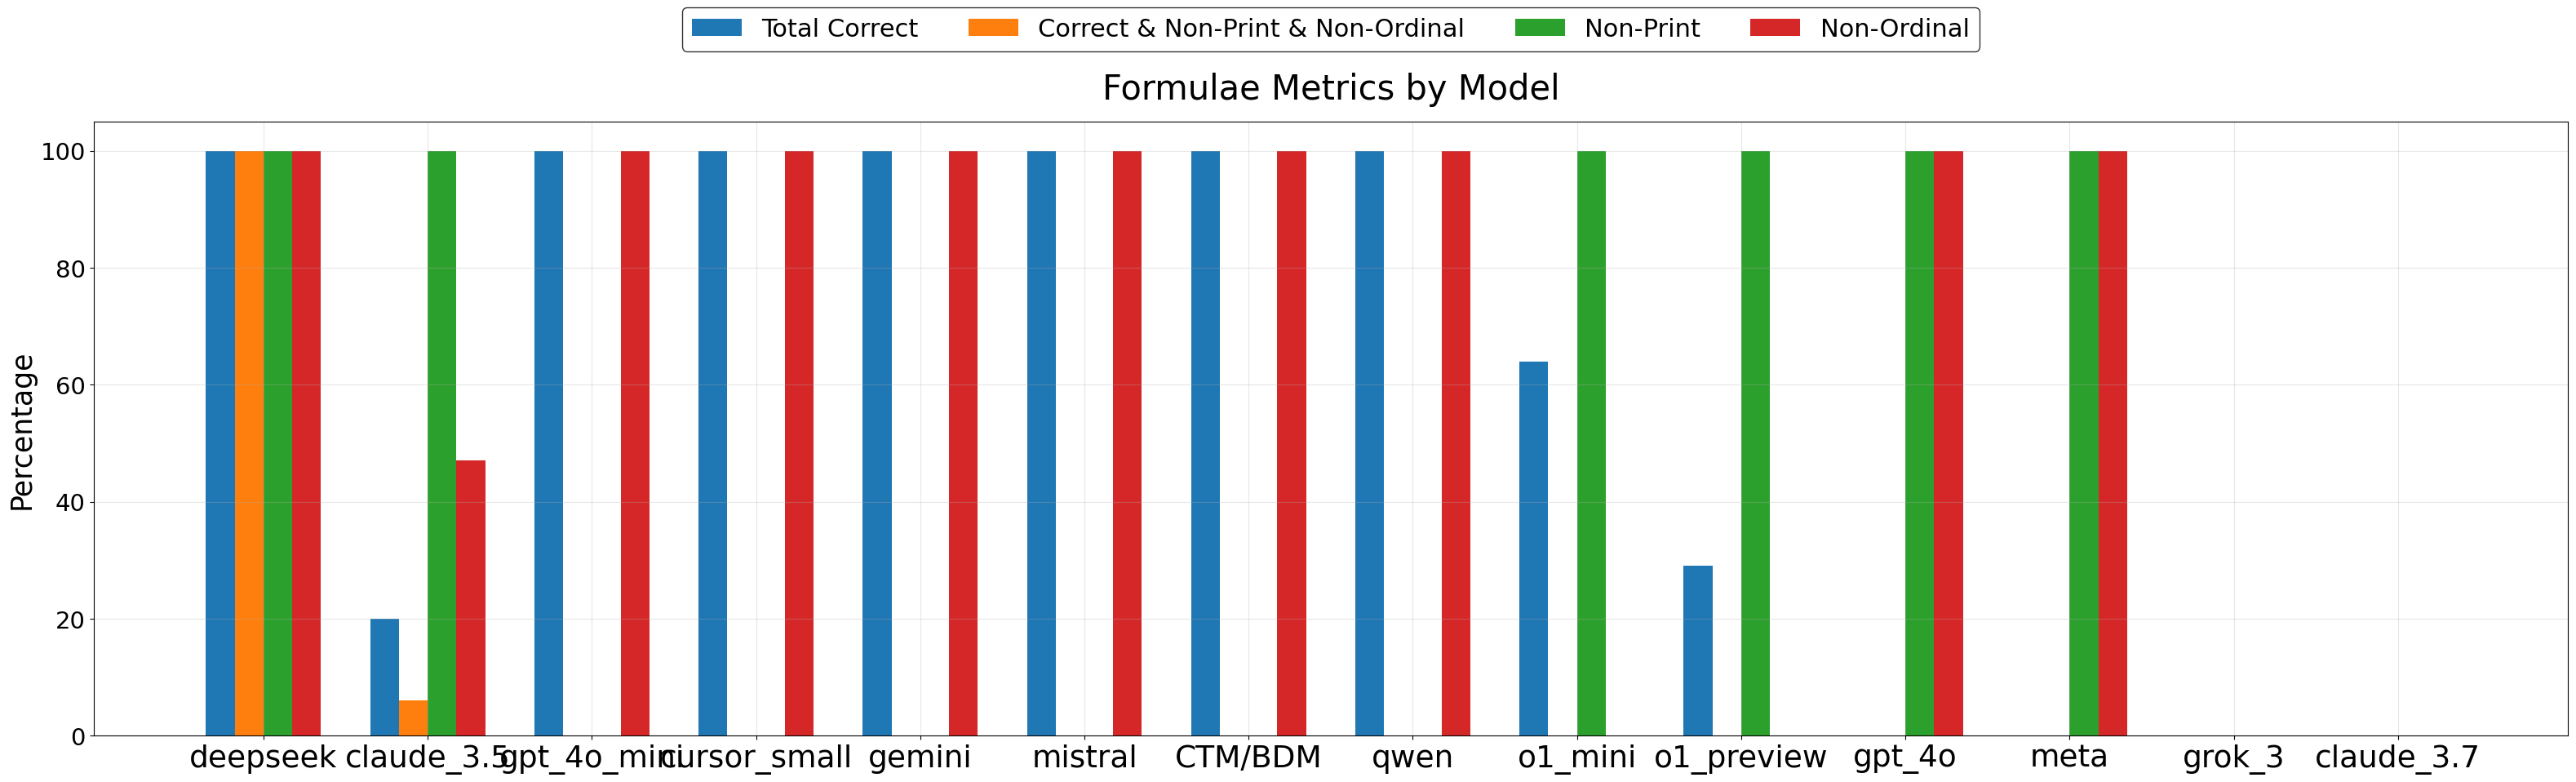

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique model names
models = ['gpt_4o', 'claude_3.5', 'gpt_4o_mini', 'cursor_small', 'gemini', 
          'meta', 'o1_mini', 'o1_preview', 'mistral', 'CTM/BDM', 'gpt-o1',
          'qwen', 'grok_3', 'deepseek', 'claude_3.7']

# Define models to exclude
excluded_models = ['CTM/BDM', 'gpt-o1']

# Initialize data storage for formulas
non_ordinal_data = []
non_copy_seq_data = []
total_correct_data = []
correct_non_both_data = [] # New array for correct & non-print & non-ordinal
prints_data = []
ordinals_data = []
correct_print_data = []
correct_ordinals_data = []

# Collect data for each model
for model in [m for m in models if m not in excluded_models]:
    corr_col = f'{model}-formula-correctness'
    ord_col = f'{model}-formula-ordinal'
    copy_col = f'{model}-formula-copy_seq'
    
    if all(col in bin_seq_df.columns for col in [corr_col, ord_col, copy_col]):
        # Calculate percentages
        non_ordinal = (~bin_seq_df[ord_col]).mean() * 100
        non_copy_seq = (~bin_seq_df[copy_col]).mean() * 100
        total_correct = bin_seq_df[corr_col].mean() * 100
        # New metric for correct & non-print & non-ordinal
        correct_non_both = (bin_seq_df[corr_col] & ~bin_seq_df[ord_col] & ~bin_seq_df[copy_col]).mean() * 100
        
        # New metrics
        prints = (bin_seq_df[copy_col]).mean() * 100
        ordinals = (bin_seq_df[ord_col]).mean() * 100
        correct_print = (bin_seq_df[corr_col] & bin_seq_df[copy_col]).mean() * 100
        correct_ordinal = (bin_seq_df[corr_col] & bin_seq_df[ord_col]).mean() * 100
         
        non_ordinal_data.append(non_ordinal)
        non_copy_seq_data.append(non_copy_seq)
        total_correct_data.append(total_correct)
        correct_non_both_data.append(correct_non_both)
        prints_data.append(prints)
        ordinals_data.append(ordinals)
        correct_print_data.append(correct_print)
        correct_ordinals_data.append(correct_ordinal)
    else:
        print(f'{model} - missing columns')
        non_ordinal_data.append(0)
        non_copy_seq_data.append(0)
        total_correct_data.append(0)
        correct_non_both_data.append(0)
        prints_data.append(0)
        ordinals_data.append(0)
        correct_print_data.append(0)
        correct_ordinals_data.append(0)

# Add CTM/BDM data with 100% for all metrics
non_ordinal_data.append(100)
non_copy_seq_data.append(100)
total_correct_data.append(100)
correct_non_both_data.append(100)
prints_data.append(0)
ordinals_data.append(0)
correct_print_data.append(0)
correct_ordinals_data.append(0)

# Add gpt-o1 data with 0% for all metrics to ensure it is last
non_ordinal_data.append(0)
non_copy_seq_data.append(0)
total_correct_data.append(0)
correct_non_both_data.append(0)
prints_data.append(0)
ordinals_data.append(0)
correct_print_data.append(0)
correct_ordinals_data.append(0)

# Create DataFrame with all metrics
df_data = {
    'model': models,
    'non_ordinal': non_ordinal_data,
    'non_copy_seq': non_copy_seq_data,
    'total_correct': total_correct_data,
    'correct_non_both': correct_non_both_data,
    'prints': prints_data,
    'ordinals': ordinals_data,
    'correct_print': correct_print_data,
    'correct_ordinals': correct_ordinals_data
}
ranking_df = pd.DataFrame(df_data)

# Calculate ranking using provided formula
ranking_df['ranking'] = (
    (ranking_df['non_copy_seq'] * ranking_df['non_ordinal'] * ranking_df['total_correct']) / 10000
    +(ranking_df['total_correct'] * (ranking_df['correct_ordinals']) * (ranking_df['correct_print']))/10000
    + (ranking_df['correct_print'] / 100) + (ranking_df['correct_ordinals'] / 1000)
    - (100-ranking_df['ordinals'])*(ranking_df['correct_ordinals']/100)
    - (100-ranking_df['prints'])*(ranking_df['correct_print']/100)
)

# Sort by ranking in descending order, ensuring 'gpt-o1' is last
ranking_df = ranking_df.sort_values('ranking', ascending=False)
ranking_df = pd.concat([ranking_df[ranking_df['model'] != 'gpt-o1'], ranking_df[ranking_df['model'] == 'gpt-o1']])

# Create figure with more height to accommodate title and legend
plt.figure(figsize=(32, 10))

# Increase font sizes
plt.rcParams.update({'font.size': 21})

# Use the sorted data
models = ranking_df['model'].tolist()
non_ordinal_data = ranking_df['non_ordinal'].tolist()
non_copy_seq_data = ranking_df['non_copy_seq'].tolist()
total_correct_data = ranking_df['total_correct'].tolist()
correct_non_both_data = ranking_df['correct_non_both'].tolist()

# Set the positions of the bars
x = np.arange(len(models) - 1) * 2  # Exclude gpt-o1 from plotting
width = 0.35

# Create subplot with adjusted height ratios
plt.subplots_adjust(top=0.85)  # Make room for title and legend

# Add title
plt.title('Formulae Metrics by Model', fontsize=30, pad=20)

# Plot all sets of data as grouped bars
plt.bar(x - 1.5*width, total_correct_data[:-1], width, label='Total Correct', color='#1f77b4')  # Exclude gpt-o1
plt.bar(x - 0.5*width, correct_non_both_data[:-1], width, label='Correct & Non-Print & Non-Ordinal', color='#ff7f0e')  # Exclude gpt-o1
plt.bar(x + 0.5*width, non_copy_seq_data[:-1], width, label='Non-Print', color='#2ca02c')  # Exclude gpt-o1
plt.bar(x + 1.5*width, non_ordinal_data[:-1], width, label='Non-Ordinal', color='#d62728')  # Exclude gpt-o1

# Customize the plot
plt.ylabel('Percentage', fontsize=25)
plt.xticks(x, models[:-1], rotation=0, fontsize=27)  # Exclude gpt-o1
plt.grid(True, alpha=0.3)

# Place legend above the plot with clear spacing
plt.legend(bbox_to_anchor=(0.5, 1.15), loc='center', ncol=4, fontsize=22, frameon=True, 
          facecolor='white', edgecolor='black')

plt.tight_layout()
plt.show()

In [5]:
ranking_df_copy = ranking_df.copy()
ranking_df_copy


,model,non_ordinal,non_copy_seq,total_correct,correct_non_both,prints,ordinals,correct_print,correct_ordinals,ranking
13,deepseek,100.0,100.0,100.0,100.0,0.0,0.0,0.0,0.0,100.000
1,claude_3.5,47.0,100.0,20.0,6.0,0.0,53.0,0.0,14.0,2.834
2,gpt_4o_mini,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000
3,cursor_small,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000
4,gemini,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000
8,mistral,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000
9,CTM/BDM,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000
11,qwen,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000
6,o1_mini,0.0,100.0,64.0,0.0,0.0,100.0,0.0,64.0,0.064
7,o1_preview,0.0,100.0,29.0,0.0,0.0,100.0,0.0,29.0,0.029


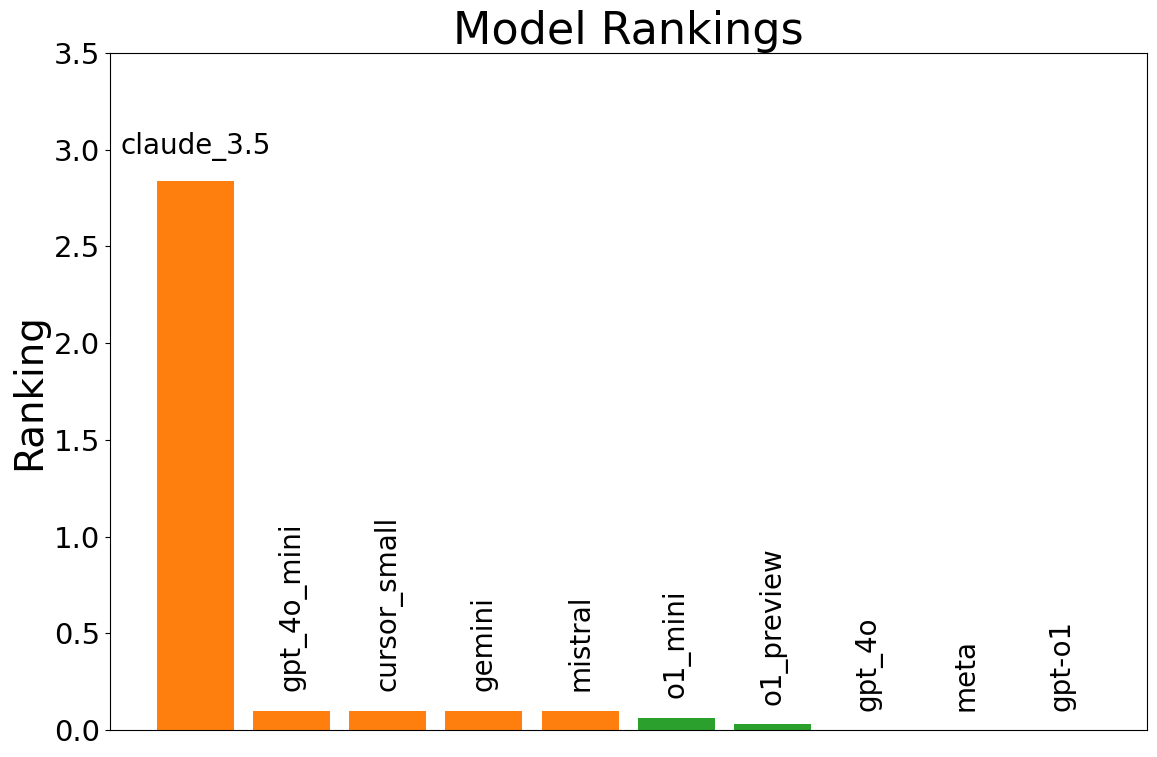

In [27]:
ranking_df_copy['Ranking'] = (
    (ranking_df_copy['non_copy_seq'] * ranking_df_copy['non_ordinal'] * ranking_df_copy['correct_non_both']) / 10000
    - (ranking_df_copy['total_correct'] * (100 - ranking_df_copy['non_ordinal']) * (100 - ranking_df_copy['non_copy_seq']) / 10000)
    + (ranking_df_copy['total_correct'] / 1000)
)
# Exclude 'CTM/BDM' from the DataFrame
ranking_df_copy = ranking_df_copy[ranking_df_copy['model'] != 'CTM/BDM']

# Sort by rank
ranking_df_copy = ranking_df_copy.sort_values('Ranking', ascending=False)
ranking_df_copy[['model', 'non_ordinal', 'non_copy_seq', 'total_correct', 'correct_non_both', 'Ranking']]

# Plot the ranking
plt.figure(figsize=(12, 8))

# Define colors using the default matplotlib color cycle
colors = plt.cm.tab10.colors  # Default color cycle

# Assign colors based on the model names
bar_colors = []
for model in ranking_df_copy['model']:
    if model in ['claude_3.5', 'gpt_4o_mini', 'cursor_small', 'gemini', 'mistral']:
        bar_colors.append(colors[1])  # Orange
    elif model in ['o1_mini', 'o1_preview']:
        bar_colors.append(colors[2])  # Green
    else:
        bar_colors.append('red')  # Red

bars = plt.bar(ranking_df_copy['model'], ranking_df_copy['Ranking'], color=bar_colors)

# Add labels above the bars
for bar, label in zip(bars, ranking_df_copy['model']):
    rotation_angle = 0 if label == 'claude_3.5' else 90  # Rotate only 'claude_3.5' to be horizontal
    plt.text(bar.get_x() + bar.get_width() / 2,  # Horizontal position
             bar.get_height() + 0.1,             # Vertical position
             label,                              # Text (model name)
             ha='center', va='bottom', fontsize=20, rotation=rotation_angle)  # Increased fontsize to 20

#plt.xlabel('Model', fontsize=28)  # Increased fontsize to 28
plt.ylabel('Ranking', fontsize=28)  # Increased fontsize to 28
plt.title('Model Rankings', fontsize=32)  # Increased fontsize to 32
plt.xticks([])  # Remove x-tick labels
plt.ylim(0, 3.5)  # Set the max in y to 3.5
plt.tight_layout()
plt.show()


In [6]:
ranking_df_copy

,model,non_ordinal,non_copy_seq,total_correct,correct_non_both,prints,ordinals,correct_print,correct_ordinals,ranking,Ranking
1,claude_3.5,47.0,100.0,20.0,6.0,0.0,53.0,0.0,14.0,2.834,2.840
2,gpt_4o_mini,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000,0.100
3,cursor_small,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000,0.100
4,gemini,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000,0.100
8,mistral,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000,0.100
6,o1_mini,0.0,100.0,64.0,0.0,0.0,100.0,0.0,64.0,0.064,0.064
7,o1_preview,0.0,100.0,29.0,0.0,0.0,100.0,0.0,29.0,0.029,0.029
0,gpt_4o,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000
5,meta,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000
10,gpt-o1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000


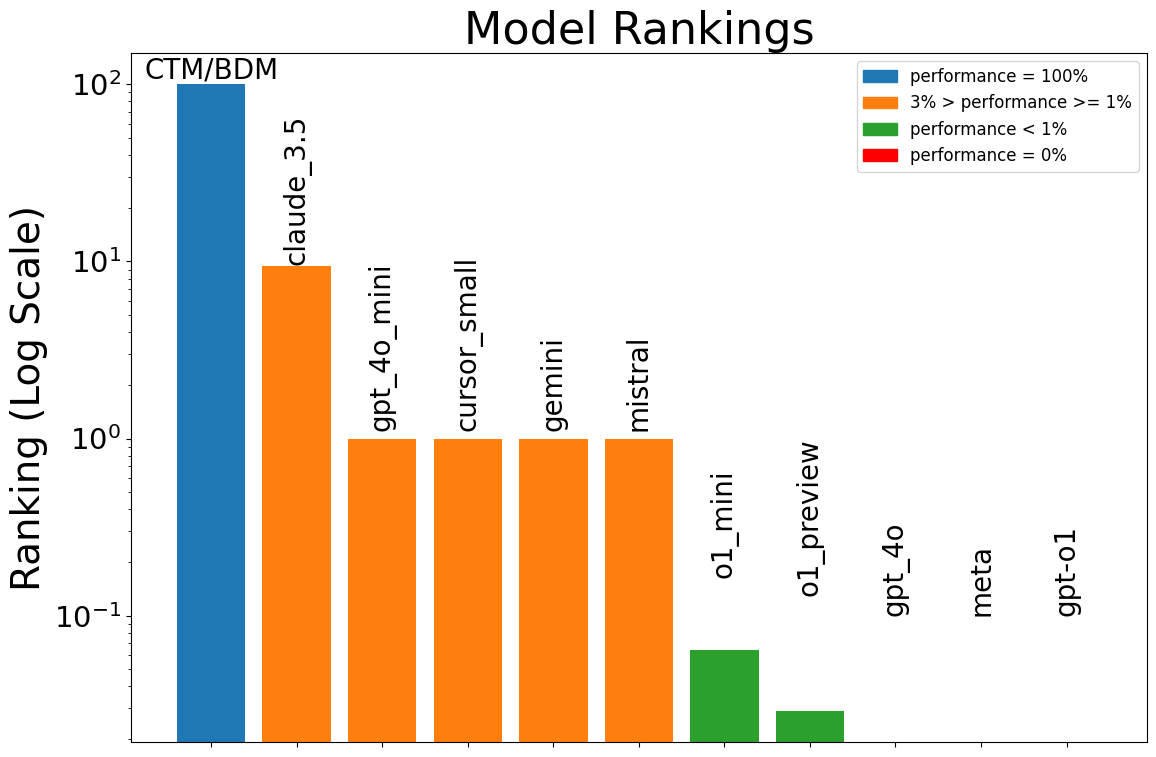

In [20]:

# Create the bar plot
plt.figure(figsize=(12, 8))

# Define colors using the default matplotlib color cycle
colors = plt.cm.tab10.colors  # Default color cycle

# Assign colors based on the model names
bar_colors = []
for model in ranking_df_copy['model']:
    if model == 'CTM/BDM':
        bar_colors.append(colors[0])  # Blue
    elif model in ['claude_3.5', 'gpt_4o_mini', 'cursor_small', 'gemini', 'mistral']:
        bar_colors.append(colors[1])  # Orange
    elif model in ['o1_mini', 'o1_preview']:
        bar_colors.append(colors[2])  # Green
    else:
        bar_colors.append('red')  # Red

# Create a legend
import matplotlib.patches as mpatches

blue_patch = mpatches.Patch(color=colors[0], label='performance = 100%')
orange_patch = mpatches.Patch(color=colors[1], label='3% > performance >= 1%')
green_patch = mpatches.Patch(color=colors[2], label='performance < 1%')
red_patch = mpatches.Patch(color='red', label='performance = 0%')

plt.legend(handles=[blue_patch, orange_patch, green_patch, red_patch], fontsize=12)

bars = plt.bar(range(len(ranking_df_copy['model'])), ranking_df_copy['ranking'], color=bar_colors)

# Add labels above the bars
for bar, label in zip(bars, ranking_df_copy['model']):
    rotation_angle = 0 if label == 'CTM/BDM' else 90  # Exclude rotation for 'CTM/BDM'
    plt.text(bar.get_x() + bar.get_width() / 2,  # Horizontal position
             bar.get_height() + 0.1,             # Vertical position
             label,                              # Text (model name)
             ha='center', va='bottom', fontsize=20, rotation=rotation_angle)  # Increased fontsize to 20

# Format plot
plt.xlabel('', fontsize=28)  # Increased fontsize to 28
plt.ylabel('Ranking (Log Scale)', fontsize=28)  # Increased fontsize to 28
plt.yscale('log')
plt.title('Model Rankings', fontsize=32)  # Increased fontsize to 32
plt.xticks(range(len(ranking_df_copy['model'])), [''] * len(ranking_df_copy['model']), rotation=0)
plt.tight_layout()
plt.show()

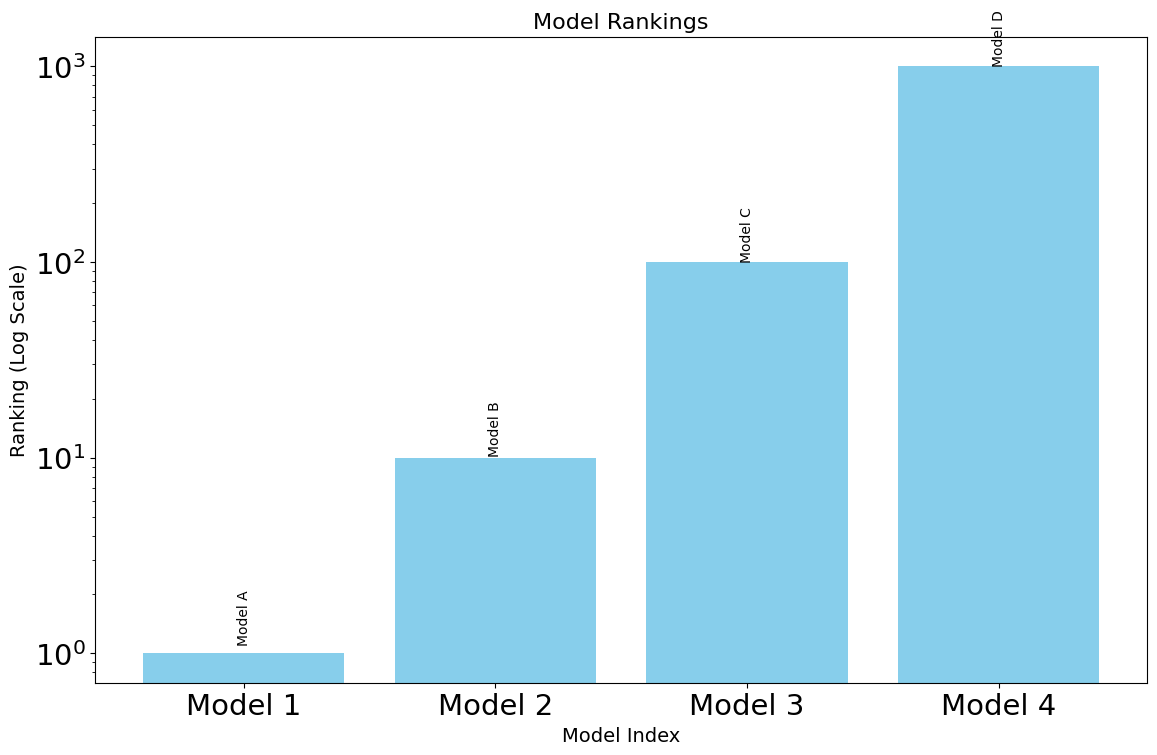

In [8]:
import matplotlib.pyplot as plt

# Example data
ranking_df_copy = {
    'model': ['Model A', 'Model B', 'Model C', 'Model D'],
    'ranking': [1, 10, 100, 1000]
}

# Create the bar plot
plt.figure(figsize=(12, 8))
bars = plt.bar(range(len(ranking_df_copy['model'])), ranking_df_copy['ranking'], color='skyblue')

# Add labels above the bars
for bar, label in zip(bars, ranking_df_copy['model']):
    plt.text(bar.get_x() + bar.get_width() / 2,  # Horizontal position
             bar.get_height() + 0.1,             # Vertical position
             label,                              # Text (model name)
             ha='center', va='bottom', fontsize=10, rotation=90)

# Format plot
plt.xlabel('Model Index', fontsize=14)
plt.ylabel('Ranking (Log Scale)', fontsize=14)
plt.yscale('log')
plt.title('Model Rankings', fontsize=16)
plt.xticks(range(len(ranking_df_copy['model'])), [f'Model {i+1}' for i in range(len(ranking_df_copy['model']))], rotation=0)
plt.tight_layout()
plt.show()


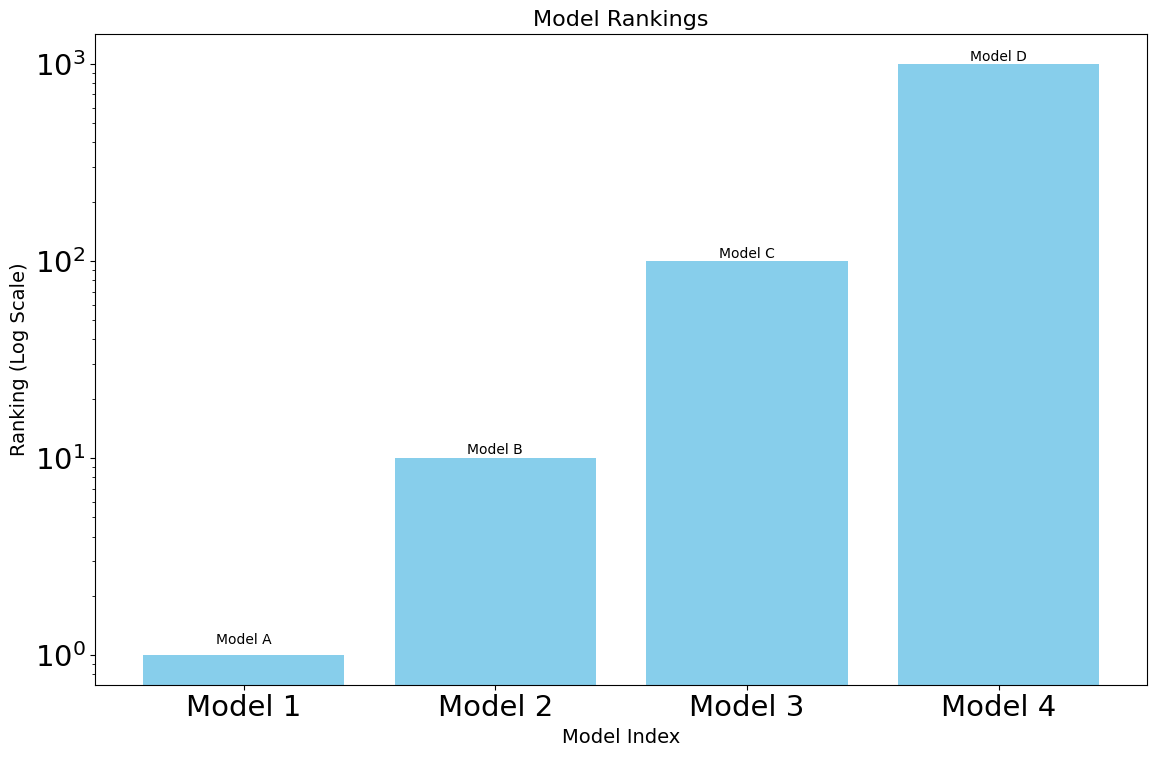

In [9]:
import matplotlib.pyplot as plt

# Example data
ranking_df_copy = {
    'model': ['Model A', 'Model B', 'Model C', 'Model D'],
    'ranking': [1, 10, 100, 1000]
}

# Create the bar plot
plt.figure(figsize=(12, 8))
bars = plt.bar(range(len(ranking_df_copy['model'])), ranking_df_copy['ranking'], color='skyblue')

# Add labels above the bars
for bar, label in zip(bars, ranking_df_copy['model']):
    plt.text(bar.get_x() + bar.get_width() / 2,  # Horizontal position
             bar.get_height() + 0.1,             # Vertical position
             label,                              # Text (model name)
             ha='center', va='bottom', fontsize=10)

# Format plot
plt.xlabel('Model Index', fontsize=14)
plt.ylabel('Ranking (Log Scale)', fontsize=14)
plt.yscale('log')
plt.title('Model Rankings', fontsize=16)
plt.xticks(range(len(ranking_df_copy['model'])), [f'Model {i+1}' for i in range(len(ranking_df_copy['model']))], rotation=0)
plt.tight_layout()
plt.show()


In [10]:
ranking_df = ranking_df.rename(columns={'non_copy_seq': 'non_print'})

In [11]:
ranking_df_copy = ranking_df.copy()
ranking_df_copy

,model,non_ordinal,non_print,total_correct,correct_non_both,prints,ordinals,correct_print,correct_ordinals,ranking
9,CTM/BDM,100.0,100.0,100.0,100.0,0.0,0.0,0.0,0.0,100.000
1,claude_3.5,47.0,100.0,20.0,6.0,0.0,53.0,0.0,14.0,2.834
2,gpt_4o_mini,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000
3,cursor_small,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000
4,gemini,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000
8,mistral,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000
6,o1_mini,0.0,100.0,64.0,0.0,0.0,100.0,0.0,64.0,0.064
7,o1_preview,0.0,100.0,29.0,0.0,0.0,100.0,0.0,29.0,0.029
0,gpt_4o,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
5,meta,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000


In [12]:
# PUNISHING CLAUDE
ranking_df_copy['ranking'] = (
    (ranking_df_copy['non_print'] * ranking_df_copy['non_ordinal'] * ranking_df_copy['total_correct']) / 10000
    +(ranking_df_copy['total_correct'] * (ranking_df_copy['correct_ordinals']) * (ranking_df_copy['correct_print']))/10000
    + (ranking_df_copy['correct_print'] / 100) + (ranking_df_copy['correct_ordinals'] / 1000)
    - (100-ranking_df_copy['ordinals'])*(ranking_df_copy['correct_ordinals']/100)
    - (100-ranking_df_copy['prints'])*(ranking_df_copy['correct_print']/100)
)
# Sort by theoretical rank
ranking_df_copy = ranking_df_copy.sort_values('ranking', ascending=False)
ranking_df_copy[['model', 'non_ordinal', 'non_print', 'total_correct', 'correct_non_both', 'ranking']]

,model,non_ordinal,non_print,total_correct,correct_non_both,ranking
9,CTM/BDM,100.0,100.0,100.0,100.0,100.000
1,claude_3.5,47.0,100.0,20.0,6.0,2.834
2,gpt_4o_mini,100.0,0.0,100.0,0.0,1.000
3,cursor_small,100.0,0.0,100.0,0.0,1.000
4,gemini,100.0,0.0,100.0,0.0,1.000
8,mistral,100.0,0.0,100.0,0.0,1.000
6,o1_mini,0.0,100.0,64.0,0.0,0.064
7,o1_preview,0.0,100.0,29.0,0.0,0.029
0,gpt_4o,100.0,100.0,0.0,0.0,0.000
5,meta,100.0,100.0,0.0,0.0,0.000


In [13]:
# PUNISHING CLAUDE
ranking_df_copy['ranking'] = (
    (ranking_df_copy['non_print'] * ranking_df_copy['non_ordinal'] * ranking_df_copy['total_correct']) / 10000
    +(ranking_df_copy['total_correct'] * (ranking_df_copy['correct_ordinals']) * (ranking_df_copy['correct_print']))/10000
    + (ranking_df_copy['correct_print'] / 100) + (ranking_df_copy['correct_ordinals'] / 1000)
    - (100-ranking_df_copy['ordinals'])*(ranking_df_copy['correct_ordinals']/100)
)
# Sort by theoretical rank
ranking_df_copy = ranking_df_copy.sort_values('ranking', ascending=False)
ranking_df_copy[['model', 'non_ordinal', 'non_print', 'total_correct', 'correct_non_both', 'ranking']]

,model,non_ordinal,non_print,total_correct,correct_non_both,ranking
9,CTM/BDM,100.0,100.0,100.0,100.0,100.000
1,claude_3.5,47.0,100.0,20.0,6.0,2.834
2,gpt_4o_mini,100.0,0.0,100.0,0.0,1.000
3,cursor_small,100.0,0.0,100.0,0.0,1.000
4,gemini,100.0,0.0,100.0,0.0,1.000
8,mistral,100.0,0.0,100.0,0.0,1.000
6,o1_mini,0.0,100.0,64.0,0.0,0.064
7,o1_preview,0.0,100.0,29.0,0.0,0.029
0,gpt_4o,100.0,100.0,0.0,0.0,0.000
5,meta,100.0,100.0,0.0,0.0,0.000


In [14]:
# *********************************************************
ranking_df_copy['ranking'] = (100-(
    (ranking_df_copy['total_correct'] * ((ranking_df_copy['correct_print']) * (ranking_df_copy['correct_ordinals'])))/100
    + (100 - ranking_df_copy['ordinals'])
    - (ranking_df_copy['correct_non_both'] *(ranking_df_copy['non_print'] * ranking_df_copy['non_ordinal']))/100
    + (100 - ranking_df_copy['total_correct'])
))/100
# Sort by theoretical rank
ranking_df_copy = ranking_df_copy.sort_values('ranking', ascending=False)
ranking_df_copy[['model', 'non_ordinal', 'non_print', 'total_correct', 'correct_non_both', 'ranking']]



,model,non_ordinal,non_print,total_correct,correct_non_both,ranking
9,CTM/BDM,100.0,100.0,100.0,100.0,100.00
1,claude_3.5,47.0,100.0,20.0,6.0,2.55
6,o1_mini,0.0,100.0,64.0,0.0,0.64
7,o1_preview,0.0,100.0,29.0,0.0,0.29
2,gpt_4o_mini,100.0,0.0,100.0,0.0,0.00
3,cursor_small,100.0,0.0,100.0,0.0,0.00
4,gemini,100.0,0.0,100.0,0.0,0.00
8,mistral,100.0,0.0,100.0,0.0,0.00
0,gpt_4o,100.0,100.0,0.0,0.0,-1.00
5,meta,100.0,100.0,0.0,0.0,-1.00


In [15]:
ranking_df_copy['ranking'] = (
    (ranking_df_copy['non_print'] * ranking_df_copy['non_ordinal'] * ranking_df_copy['total_correct']) / 10000
    +(ranking_df_copy['total_correct'] * (ranking_df_copy['correct_ordinals']) * (ranking_df_copy['correct_print']))/10000
    + (ranking_df_copy['correct_print'] / 100) + (ranking_df_copy['correct_ordinals'] / 1000)
)
# Sort by theoretical rank
ranking_df_copy = ranking_df_copy.sort_values('ranking', ascending=False)
ranking_df_copy[['model', 'non_ordinal', 'non_print', 'total_correct', 'correct_non_both', 'ranking']]

,model,non_ordinal,non_print,total_correct,correct_non_both,ranking
9,CTM/BDM,100.0,100.0,100.0,100.0,100.000
1,claude_3.5,47.0,100.0,20.0,6.0,9.414
2,gpt_4o_mini,100.0,0.0,100.0,0.0,1.000
3,cursor_small,100.0,0.0,100.0,0.0,1.000
4,gemini,100.0,0.0,100.0,0.0,1.000
8,mistral,100.0,0.0,100.0,0.0,1.000
6,o1_mini,0.0,100.0,64.0,0.0,0.064
7,o1_preview,0.0,100.0,29.0,0.0,0.029
0,gpt_4o,100.0,100.0,0.0,0.0,0.000
5,meta,100.0,100.0,0.0,0.0,0.000


In [16]:
ranking_df

,model,non_ordinal,non_print,total_correct,correct_non_both,prints,ordinals,correct_print,correct_ordinals,ranking
9,CTM/BDM,100.0,100.0,100.0,100.0,0.0,0.0,0.0,0.0,100.000
1,claude_3.5,47.0,100.0,20.0,6.0,0.0,53.0,0.0,14.0,2.834
2,gpt_4o_mini,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000
3,cursor_small,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000
4,gemini,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000
8,mistral,100.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,1.000
6,o1_mini,0.0,100.0,64.0,0.0,0.0,100.0,0.0,64.0,0.064
7,o1_preview,0.0,100.0,29.0,0.0,0.0,100.0,0.0,29.0,0.029
0,gpt_4o,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
5,meta,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000


In [17]:
import numpy as np
import zlib
import lzma
import base64

In [18]:
def convert_to_numeric(string_list):
    return list(map(int, string_list.split(',')))

def to_number(list_strings):
    return [list(map(int, num_str.split(','))) for num_str in list_strings]

def to_digit_lists(number_strings):
    def to_binary(num, length=4):
        return [int(b) for b in format(num, f'0{length}b')]

    all_digits_lists = []
    
    for number_string in number_strings:
        number_list = number_string.split(',')
        digit_list = []
        for number in number_list:
            for char in number.strip():
                digit_list.extend(to_binary(int(char)))
        all_digits_lists.append(digit_list)
    
    return all_digits_lists

def normalize_binary_sequences(binary_seq):
    # a) Compute average length
    avg_length = round(np.mean([len(seq) for seq in binary_seq]))
    
    # b) Clean list based on average length
    clean_binary_seq_by_avg = [
        np.array(seq[:avg_length], dtype=int) for seq in binary_seq if len(seq) >= avg_length
    ]
    
    return avg_length, clean_binary_seq_by_avg

from pybdm import BDM
def compute_avg_bdm(norm_bin_sequences_list):
    bdm = BDM(ndim=1)
    
    # Compute BDM for each sequence
    bdm_values = [bdm.bdm(seq) for seq in norm_bin_sequences_list]
    
    # Calculate the average BDM
    avg_bdm = np.mean(bdm_values)
    
    return avg_bdm

def compress_text(text):
    # Apply LZW compression using lzma (LZMA is a variant of LZW)
    lzw_compressed = lzma.compress(text.encode('utf-8'))
    
    # Apply ZIP compression using zlib
    zip_compressed = zlib.compress(text.encode('utf-8'))
    
    # Encode the compressed data to Base64
    lzw_compressed_base64 = base64.b64encode(lzw_compressed).decode('utf-8')
    zip_compressed_base64 = base64.b64encode(zip_compressed).decode('utf-8')
    
    return lzw_compressed_base64, zip_compressed_base64

def decompress_text(lzw_compressed_base64, zip_compressed_base64):
    # Decode the Base64 encoded string
    lzw_compressed = base64.b64decode(lzw_compressed_base64)
    zip_compressed = base64.b64decode(zip_compressed_base64)
    
    # Decompress LZW
    lzw_decompressed = lzma.decompress(lzw_compressed).decode('utf-8')
    
    # Decompress ZIP
    zip_decompressed = zlib.decompress(zip_compressed).decode('utf-8')
    
    return lzw_decompressed, zip_decompressed
    
    
def ascii_to_binary_list(text):
    binary_list = []
    for char in text:
        # Convert each character to its binary representation
        binary_representation = format(ord(char), '08b')
        # Extend the binary_list with the numerical digits of the binary representation
        binary_list.extend([int(bit) for bit in binary_representation])
    return binary_list
    
def list_of_strings_to_binary_lists(strings_list):
    binary_lists = [ascii_to_binary_list(string) for string in strings_list]
    return binary_lists

def list_of_strings_to_compressed(strings_list):
    lzw_compressed_list = []
    zip_compressed_list = []
    
    for string in strings_list:
        lzw_compressed, zip_compressed = compress_text(string)
        lzw_compressed_list.append(lzw_compressed)
        zip_compressed_list.append(zip_compressed)
    
    return lzw_compressed_list, zip_compressed_list


import numpy as np
from pybdm import BDM

def normalize_multiple_binary_sequences(binary_seq_sets):
    # a) Compute average length for each set
    avg_lengths = [round(np.mean([len(seq) for seq in binary_seq])) for binary_seq in binary_seq_sets]
    
    # b) Select the lower calculated average
    min_avg_length = min(avg_lengths)
    
    # c) Modify each sequence in each set to the lower average length
    normalized_sets = [
        [np.array(seq[:min_avg_length], dtype=int) for seq in binary_seq if len(seq) >= min_avg_length]
        for binary_seq in binary_seq_sets
    ]
    
    return min_avg_length, normalized_sets

def compute_avg_bdm(norm_bin_sequences_list):
    bdm = BDM(ndim=1)
    bdm_values = [bdm.bdm(seq) for seq in norm_bin_sequences_list]
    shannon_values = [bdm.ent(seq) for seq in norm_bin_sequences_list]
    return np.mean(bdm_values), np.mean(shannon_values)

def list_of_lists_to_np_arrays(list_of_lists):
    return [np.array(sublist) for sublist in list_of_lists]

def transform_to_np_arrays(list_of_lists_of_lists):
    return [list_of_lists_to_np_arrays(sublist) for sublist in list_of_lists_of_lists]


def process_binary_sequences(binary_seq_sets, normalize=True):
    # Normalize all sets to the minimum average length
    if normalize == False:
        min_avg_length = None
        normalized_bin_sets = transform_to_np_arrays(binary_seq_sets)
    else:
        min_avg_length, normalized_bin_sets = normalize_multiple_binary_sequences(binary_seq_sets)
    
    # d) Calculate avg bdm and avg shannon for each normalized set
    avg_bdm_values, avg_shannon_values = zip(*(compute_avg_bdm(norm_set) for norm_set in normalized_bin_sets))
    
    return min_avg_length, list(avg_bdm_values), list(avg_shannon_values)

In [19]:
# 'gpt_4o', 'claude_3.5', 'gpt_4o_mini', 'cursor_small', 'gemini', 'Meta', 'o1_mini'
gpt_4o_prg = bin_seq_df['gpt_4o-program']
gpt_4o_frm = bin_seq_df['gpt_4o-formula']
claude_prg = bin_seq_df['claude_3.5-program']
claude_frm = bin_seq_df['claude_3.5-formula']
gpt_4o_mini_prg = bin_seq_df['gpt_4o_mini-program']
gpt_4o_mini_frm = bin_seq_df['gpt_4o_mini-formula']
cursor_small_prg = bin_seq_df['cursor_small-program']
cursor_small_frm = bin_seq_df['cursor_small-formula']
gemini_prg = bin_seq_df['gemini-program']
gemini_frm = bin_seq_df['gemini-formula']
meta_prg = bin_seq_df['Meta-program']
meta_frm = bin_seq_df['Meta-formula']
o1_mini_prg = bin_seq_df['o1_mini-program']
o1_mini_frm = bin_seq_df['o1_mini-formula']
o1_preview_prg = bin_seq_df['o1_preview-program']
o1_preview_frm = bin_seq_df['o1_preview-formula']

print("gpt_4o_prg, gpt_4o_frm, claude_prg, claude_frm, gpt_4o_mini_prg, gpt_4o_mini_frm, cursor_small_prg, cursor_small_frm, gemini_prg, gemini_frm, meta_prg, meta_frm, o1_mini_prg, o1_mini_frm, o1_preview_prg, o1_preview_frm")


KeyError: 'Meta-program'

In [ ]:
def average_length_of_strings(strings_list):
    total_length = sum(len(s) for s in strings_list)
    return total_length / len(strings_list) if strings_list else 0

# Function to process sequences for a single model
def process_model_sequences(sequences):
    bin_sequences = list_of_strings_to_binary_lists(sequences)
    
    # Process sequences
    _, avg_bdm, avg_shannon = process_binary_sequences([bin_sequences], normalize=False)
    
    # Process with list_of_strings_to_compressed
    lzw_compressed, zip_compressed = list_of_strings_to_compressed(sequences)
    
    # Convert LZW and ZIP results to binary
    bin_lzw = list_of_strings_to_binary_lists(lzw_compressed)
    bin_zip = list_of_strings_to_binary_lists(zip_compressed)
    
    # Process LZW and ZIP binary sequences
    _, avg_bdm_lzw, avg_shannon_lzw = process_binary_sequences([bin_lzw], normalize=False)
    _, avg_bdm_zip, avg_shannon_zip = process_binary_sequences([bin_zip], normalize=False)
    
    # Calculate average lengths
    avg_lzw = average_length_of_strings(lzw_compressed)
    avg_zip = average_length_of_strings(zip_compressed)
    
    # Convert any None values to 0 to ensure numeric data
    return {
        'avg_bdm': avg_bdm[0] if avg_bdm else 0,
        'avg_shannon': avg_shannon[0] if avg_shannon else 0,
        'avg_lzw': float(avg_lzw) if avg_lzw is not None else 0,
        'avg_zip': float(avg_zip) if avg_zip is not None else 0,
        'avg_bdm_lzw': avg_bdm_lzw[0] if avg_bdm_lzw else 0,
        'avg_shannon_lzw': avg_shannon_lzw[0] if avg_shannon_lzw else 0,
        'avg_bdm_zip': avg_bdm_zip[0] if avg_bdm_zip else 0,
        'avg_shannon_zip': avg_shannon_zip[0] if avg_shannon_zip else 0
    }

# Dictionary to store results
results_program = {}
results_formula = {}

# Process all models - Programs
model_sequences_program = {
    'gpt_4o': gpt_4o_prg,
    'claude': claude_prg,
    'gpt_4o_mini': gpt_4o_mini_prg,
    'cursor_small': cursor_small_prg,
    'gemini': gemini_prg,
    'meta': meta_prg,
    'o1_mini': o1_mini_prg,
    'o1_preview': o1_preview_prg
}

# Process all models - Formulas
model_sequences_formula = {
    'gpt_4o': gpt_4o_frm,
    'claude': claude_frm,
    'gpt_4o_mini': gpt_4o_mini_frm,
    'cursor_small': cursor_small_frm,
    'gemini': gemini_frm,
    'meta': meta_frm,
    'o1_mini': o1_mini_frm,
    'o1_preview': o1_preview_frm
}

for model, sequences in model_sequences_program.items():
    results_program[model] = process_model_sequences(sequences)

for model, sequences in model_sequences_formula.items():
    results_formula[model] = process_model_sequences(sequences)

import json
print("Results dictionaries created for plotting:")
print("\nProgram results:")
print(json.dumps(results_program, indent=4))
print("\nFormula results:")
print(json.dumps(results_formula, indent=4))

# Create visualization of results
import matplotlib.pyplot as plt
import pandas as pd

# Convert results to DataFrames for easier plotting
df_results_program = pd.DataFrame.from_dict(results_program, orient='index')
df_results_formula = pd.DataFrame.from_dict(results_formula, orient='index')

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))

# Plot metrics for programs
metrics = df_results_program.columns
ax1.set_yscale('log')

for metric in metrics:
    line = ax1.plot(df_results_program.index, df_results_program[metric], marker='o')
    last_value = df_results_program[metric].iloc[-1]
    ax1.text(df_results_program.index[-1], last_value, f' {metric}',
             fontsize=14, verticalalignment='center')

ax1.set_title('Program Metrics Across Models (Log Scale)', fontsize=21)
ax1.grid(True)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)

# Plot metrics for formulas
ax2.set_yscale('log')

for metric in metrics:
    line = ax2.plot(df_results_formula.index, df_results_formula[metric], marker='o')
    last_value = df_results_formula[metric].iloc[-1]
    ax2.text(df_results_formula.index[-1], last_value, f' {metric}',
             fontsize=14, verticalalignment='center')

ax2.set_title('Formula Metrics Across Models (Log Scale)', fontsize=21)
ax2.grid(True)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

# Save results to CSV
df_results_program.reset_index(inplace=True)
df_results_formula.reset_index(inplace=True)
df_results_program.rename(columns={'index': 'model'}, inplace=True)
df_results_formula.rename(columns={'index': 'model'}, inplace=True)
df_results_program.to_csv('binary_seq_LLM_program_metrics.csv', index=False)
df_results_formula.to_csv('binary_seq_LLM_formula_metrics.csv', index=False)